In [30]:
import numpy as np
import pandas as pd
import mlflow
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
from geopy.distance import geodesic
import yfinance as yf
import openpyxl
import seaborn as sns
from datetime import datetime
from mlflow.models import infer_signature
from dotenv import load_dotenv

load_dotenv()

True

In [31]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("rice_price_product_experiments")

<Experiment: artifact_location='s3://mlflowbucket/6', creation_time=1774452524514, experiment_id='6', last_update_time=1774452524514, lifecycle_stage='active', name='rice_price_product_experiments', tags={}, workspace='default'>

In [32]:
rice_data = pd.read_csv('./data/data_warehouse/mdg_rice_data.csv')
rice_data = rice_data[rice_data['commodity'] == 'Rice (local)']

In [33]:
alaotra = rice_data.iloc[0].latitude, rice_data.iloc[0].longitude
marovoay = -16.1073563, 46.6463975
toamasina = -18.15, 49.4167

In [34]:
distance_alaotra = [geodesic(alaotra, (lat, long)).km for lat, long in zip(rice_data["latitude"].values, rice_data["longitude"].values)]
distance_marovoay = [geodesic(marovoay, (lat, long)).km for lat, long in zip(rice_data["latitude"].values, rice_data["longitude"].values)]
distance_port = [geodesic(toamasina, (lat, long)).km for lat, long in zip(rice_data["latitude"].values, rice_data["longitude"].values)]

rice_data["distance_alaotra"] = distance_alaotra
rice_data["distance_marovoay"] = distance_marovoay
rice_data["distance_toamasina"] = distance_port

rice_data.head()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,...,diesel_price,kerosene_price,Phosphate rock,DAP,TSP,Urea,Potassium chloride,distance_alaotra,distance_marovoay,distance_toamasina
0,2015-12-15,Alaotra Mangoro,Ambatondrazaka,Alaotra Mangoro (Region),754,-17.84,48.41,cereals and tubers,Rice (local),71,...,3070.0,2290.0,123.5,340.625,360.0,264.0,301.5,0.000000,268.407502,112.002124
1,2015-12-15,Betsiboka,Maevatanana,Betsiboka (Region),762,-16.96,46.83,cereals and tubers,Rice (local),71,...,3070.0,2290.0,123.5,340.625,360.0,264.0,301.5,194.088655,96.371072,304.563876
2,2015-12-15,Analamanga,Antananarivo Renivohitra,Analamanga (Region),753,-18.93,47.52,cereals and tubers,Rice (local),71,...,3070.0,2290.0,123.5,340.625,360.0,264.0,301.5,152.971810,325.875667,218.065546
3,2015-12-15,Anosy,Taolagnaro,Anosy (Region),759,-25.03,46.98,cereals and tubers,Rice (local),71,...,3070.0,2290.0,123.5,340.625,360.0,264.0,301.5,809.762574,988.464598,802.426745
4,2015-12-15,Atsimo Atsinanana,Farafangana,Atsimo Atsinanana (Region),752,-22.82,47.82,cereals and tubers,Rice (local),71,...,3070.0,2290.0,123.5,340.625,360.0,264.0,301.5,554.759571,753.212678,543.170136


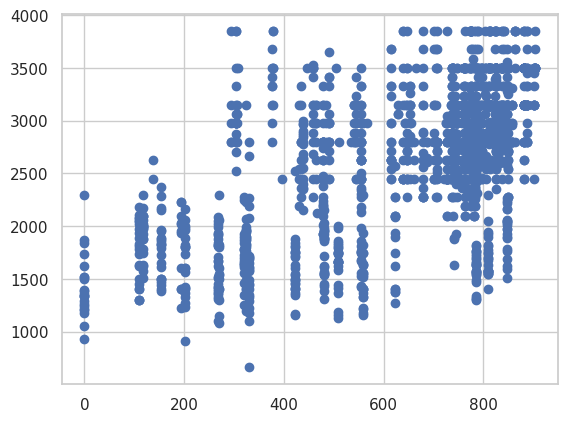

In [35]:
plt.scatter(rice_data["distance_alaotra"].values, rice_data["price"].values)

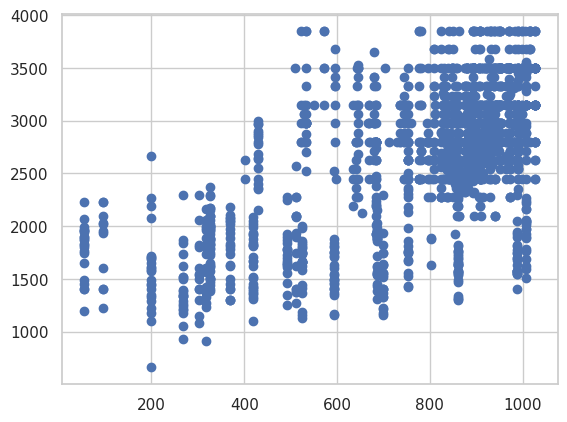

In [36]:
plt.scatter(rice_data["distance_marovoay"].values, rice_data["price"].values)

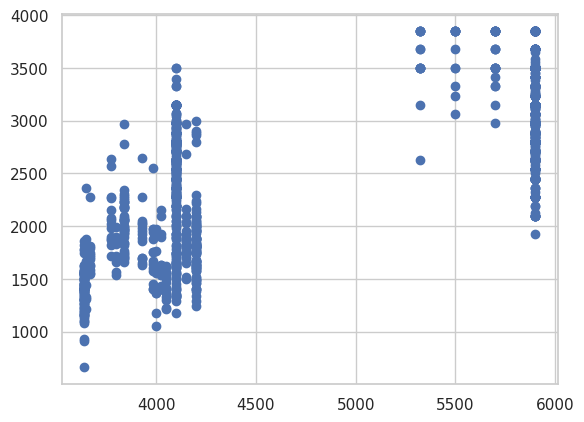

In [37]:
plt.scatter(rice_data["gasoline_price"].values, rice_data["price"].values)

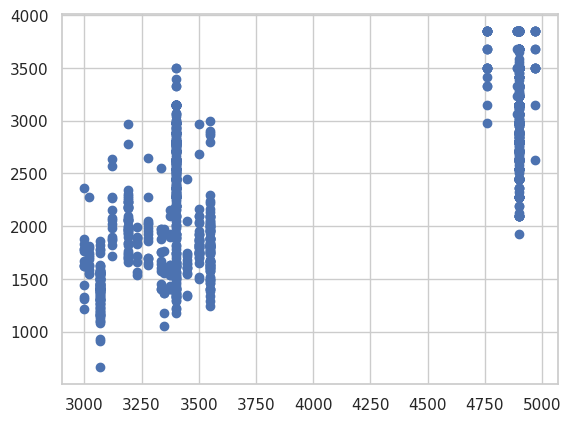

In [38]:
plt.scatter(rice_data["diesel_price"].values, rice_data["price"].values)

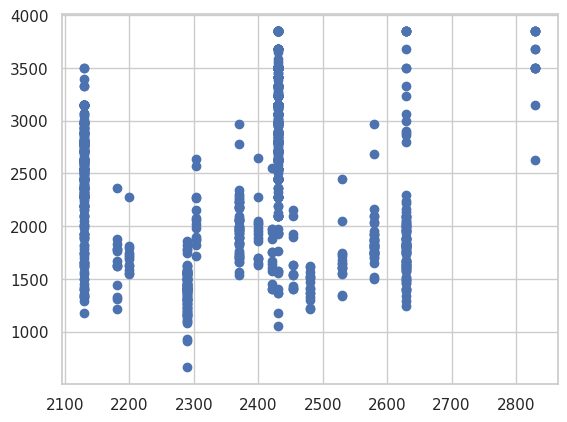

In [39]:
plt.scatter(rice_data["kerosene_price"].values, rice_data["price"].values)

In [40]:
data = yf.download("USDMGA=X", start="2015-01-01", end="2026-03-24")

[*********************100%***********************]  1 of 1 completed


In [41]:
currency_data = data.resample("MS").mean()["Close"]
currency_data = currency_data.reset_index()
currency_data.columns = [col.lower() for col in currency_data.columns]
currency_data['date'] = pd.to_datetime(currency_data["date"])

In [42]:
rice_data = rice_data.sort_values('date')
currency_data = currency_data.sort_values('date')

In [43]:
rice_data["date"] = pd.to_datetime(rice_data["date"])

In [44]:
rice_data = pd.merge_asof(
            rice_data, 
            currency_data[['date','usdmga=x']],
            on='date', 
            direction='backward'
        )

rice_data.head()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,...,kerosene_price,Phosphate rock,DAP,TSP,Urea,Potassium chloride,distance_alaotra,distance_marovoay,distance_toamasina,usdmga=x
0,2015-12-15,Alaotra Mangoro,Ambatondrazaka,Alaotra Mangoro (Region),754,-17.84,48.41,cereals and tubers,Rice (local),71,...,2290.0,123.5,340.625,360.0,264.0,301.5,0.000000,268.407502,112.002124,3156.078242
1,2015-12-15,Ihorombe,Ihosy,Ihorombe (Region),742,-22.40,46.13,cereals and tubers,Rice (local),71,...,2290.0,123.5,340.625,360.0,264.0,301.5,558.249107,698.680001,582.394459,3156.078242
2,2015-12-15,Vatovavy Fitovinany,Manakara Atsimo,Vatovavy Fitovinany (Region),745,-22.16,48.01,cereals and tubers,Rice (local),71,...,2290.0,123.5,340.625,360.0,264.0,301.5,480.071444,685.162344,467.644846,3156.078242
3,2015-12-15,Vakinankaratra,Antsirabe I,Vakinakaratra (Region),751,-19.87,47.04,cereals and tubers,Rice (local),71,...,2290.0,123.5,340.625,360.0,264.0,301.5,267.080082,418.531878,314.416342,3156.078242
4,2015-12-15,Diana,Antsiranana I,Diana (Region),746,-12.28,49.29,cereals and tubers,Rice (local),71,...,2290.0,123.5,340.625,360.0,264.0,301.5,622.440792,510.601954,649.667584,3156.078242


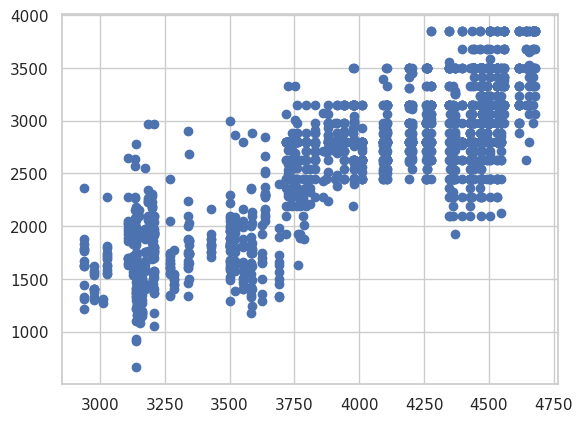

In [45]:
plt.scatter(rice_data["usdmga=x"].values, rice_data["price"].values)

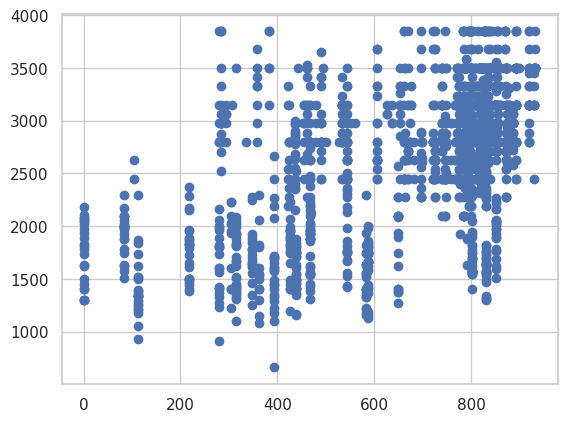

In [46]:
plt.scatter(rice_data["distance_toamasina"].values, rice_data["price"].values)

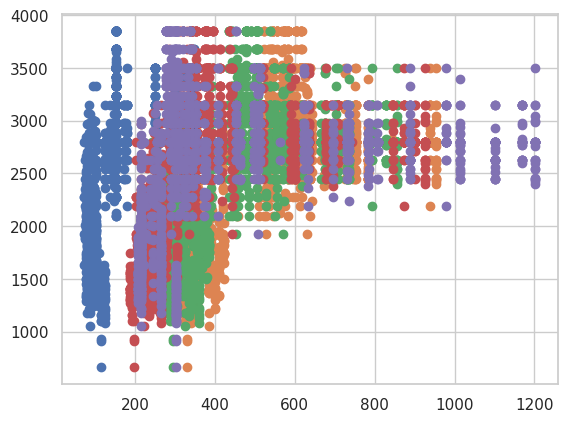

In [47]:
for fertil in ['Phosphate rock', 'DAP', 'TSP', 'Urea', 'Potassium chloride']:
    plt.scatter(rice_data[fertil], rice_data["price"])

In [48]:
sns.set_theme(style="whitegrid")

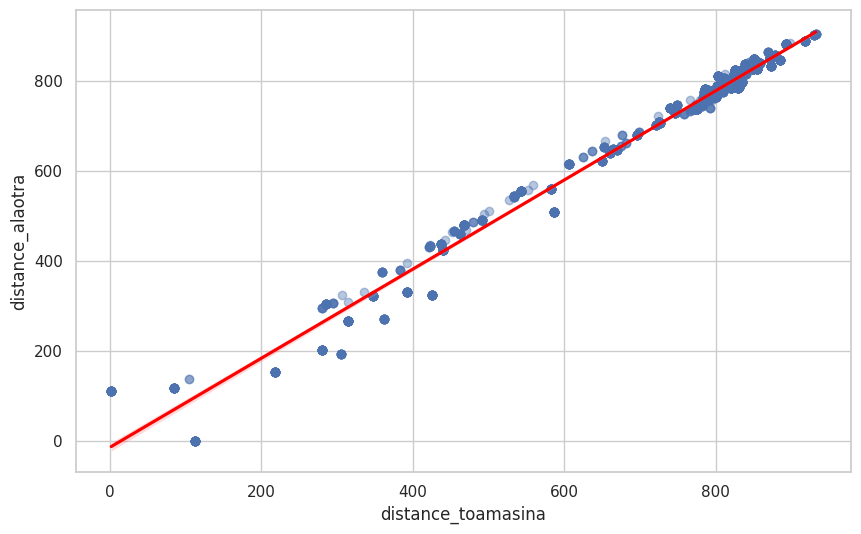

In [49]:
plt.figure(figsize=(10,6))
sns.regplot(
    data=rice_data,
    x='distance_toamasina',
    y= 'distance_alaotra',
    scatter_kws={'alpha': 0.4},
    line_kws={'color': 'red'}
    )
# plt.title(f"price = f('{feat}')")
plt.show()

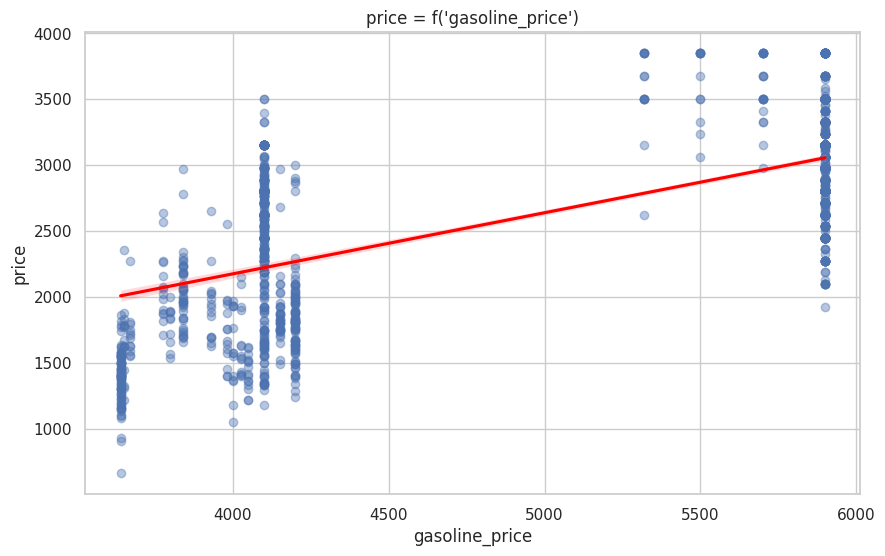

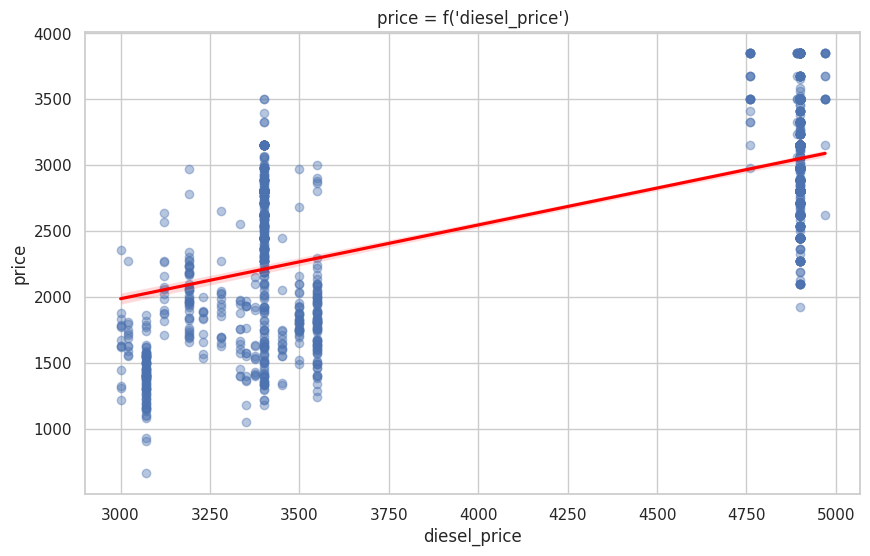

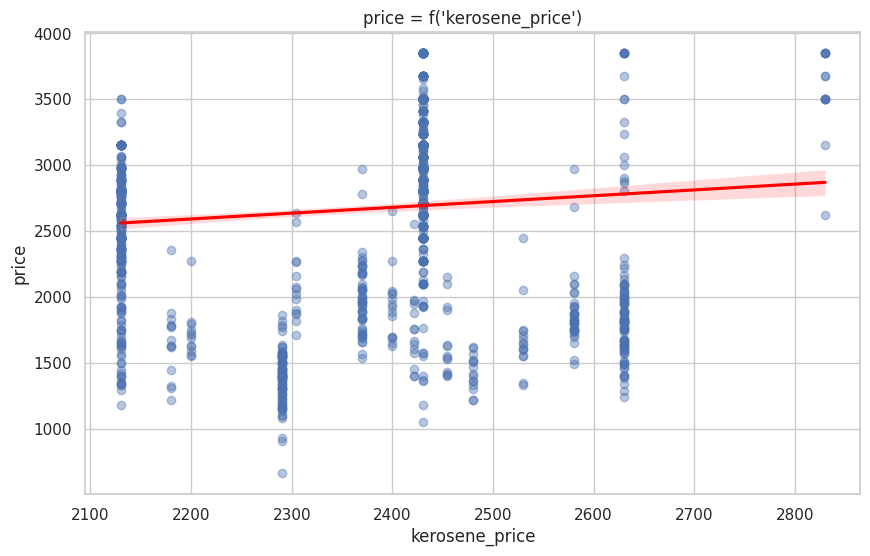

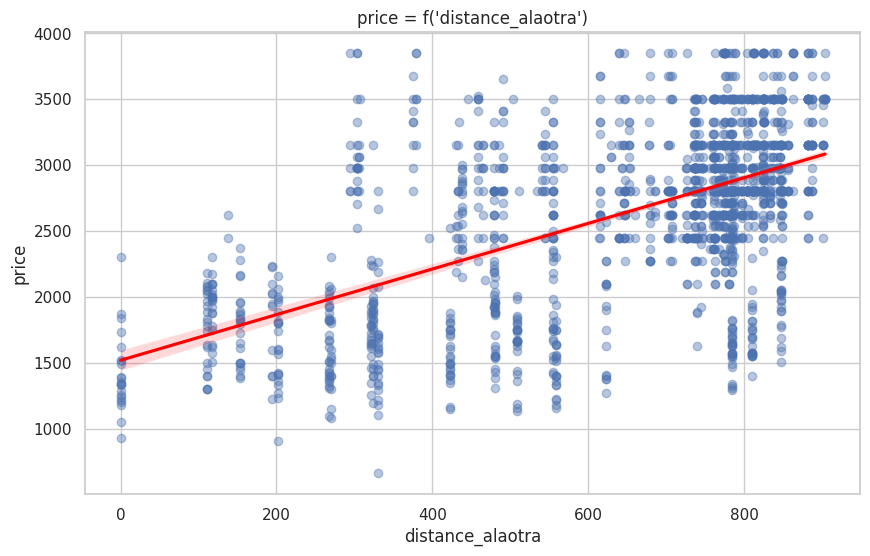

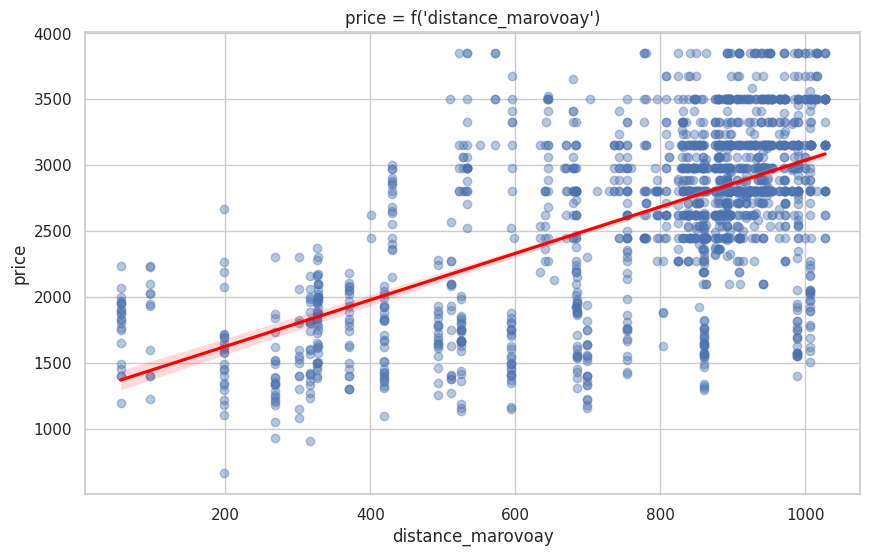

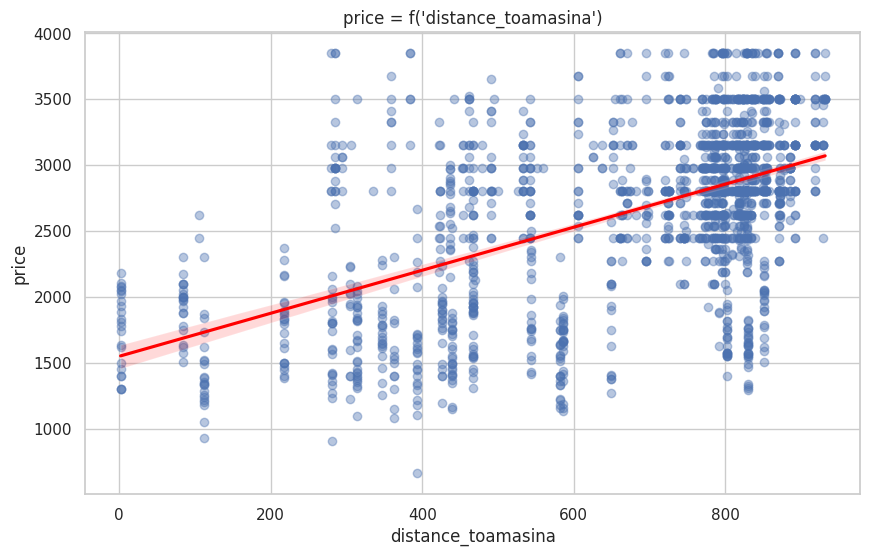

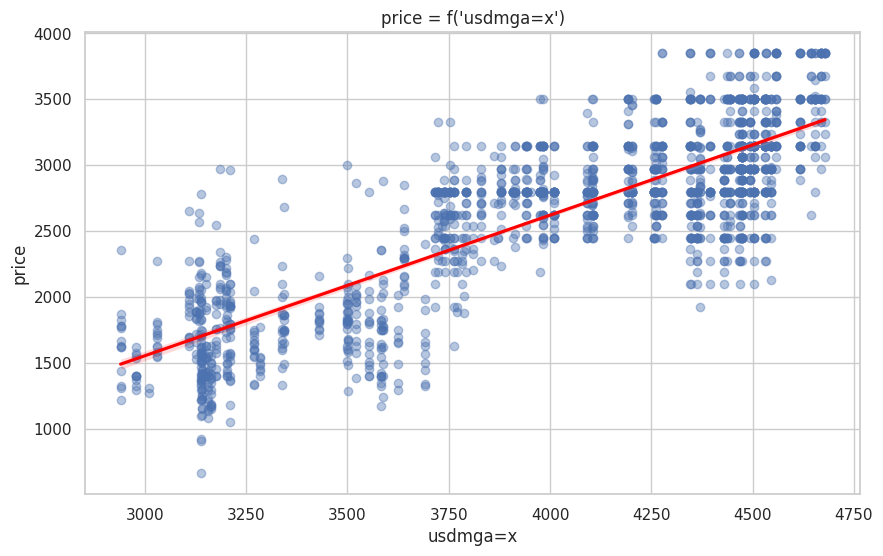

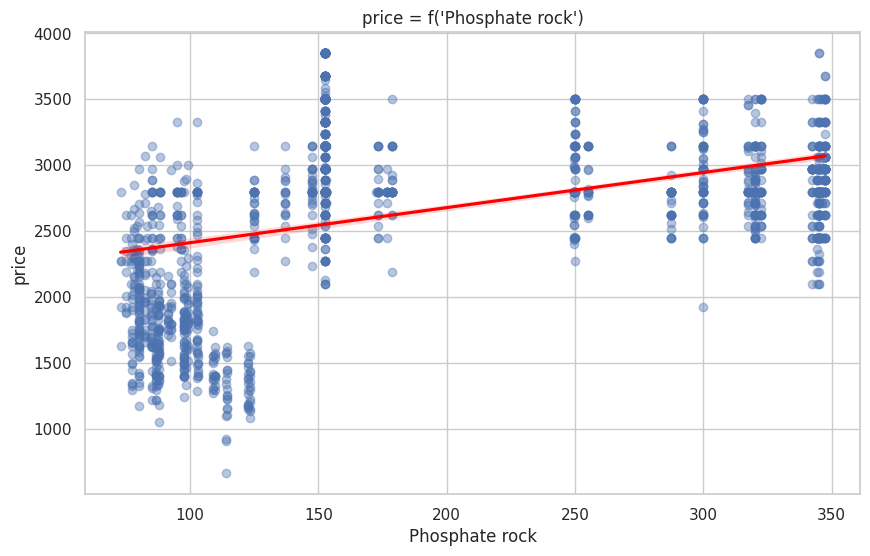

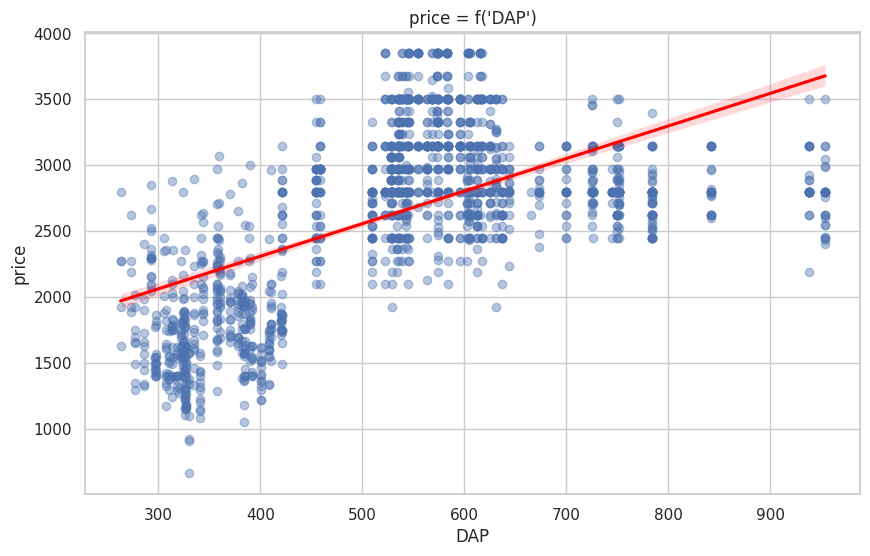

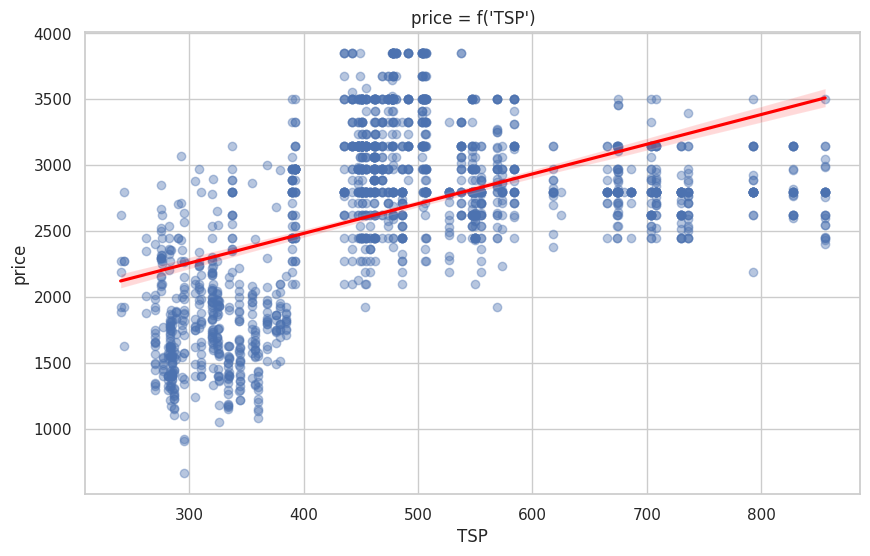

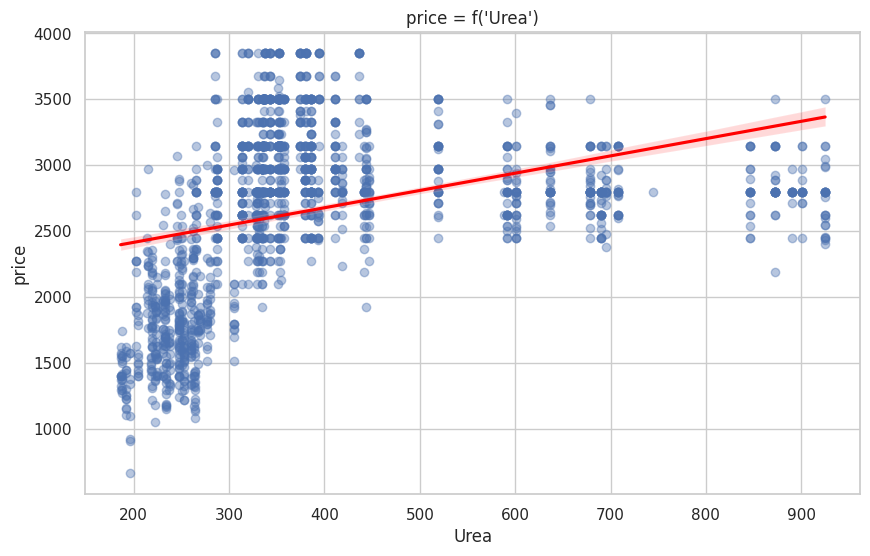

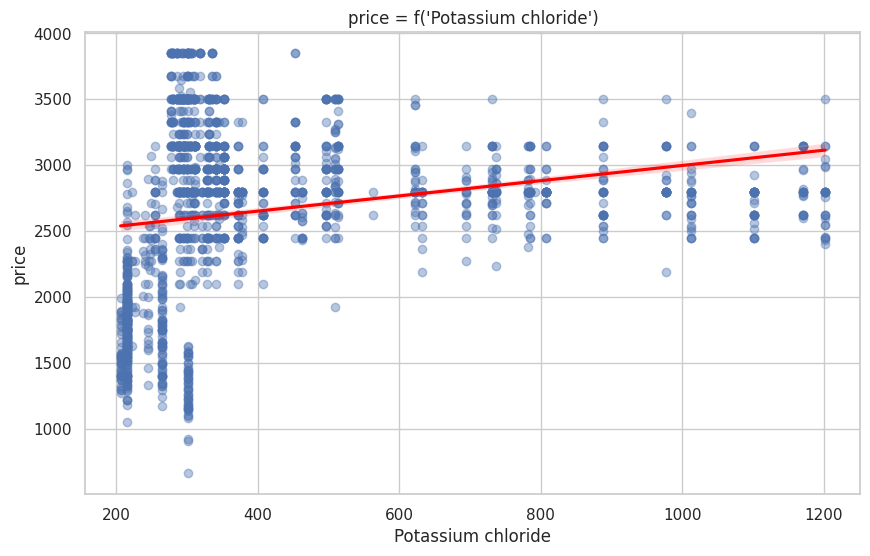

In [50]:
for feat in ['gasoline_price', 'diesel_price', 'kerosene_price', 'distance_alaotra',
       'distance_marovoay', 'distance_toamasina', 'usdmga=x', 'Phosphate rock',
       'DAP', 'TSP', 'Urea', 'Potassium chloride']:
    plt.figure(figsize=(10,6))
    sns.regplot(
        data=rice_data,
        x=feat,
        y= 'price',
        scatter_kws={'alpha': 0.4},
        line_kws={'color': 'red'}
        )
    plt.title(f"price = f('{feat}')")
    plt.show()

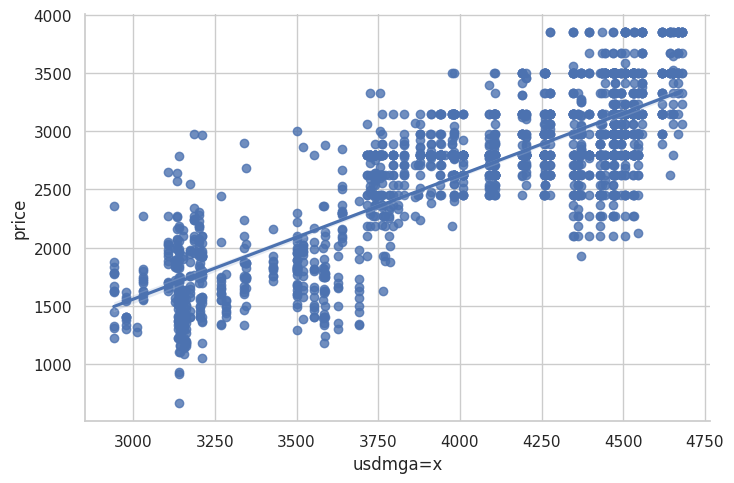

In [51]:
sns.lmplot(data=rice_data, x='usdmga=x', y='price', aspect=1.5)

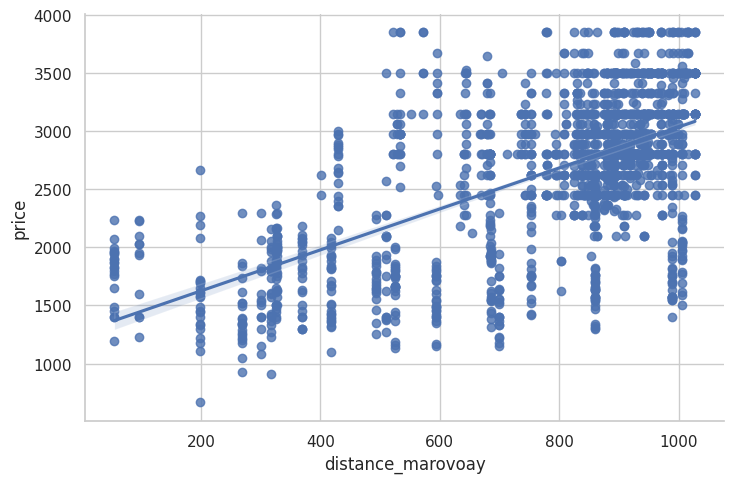

In [52]:
sns.lmplot(data=rice_data, x='distance_marovoay', y='price', aspect=1.5)

In [53]:
model = LinearRegression()

predictors = ["usdmga=x"]
target = "price"

In [54]:
data_split = TimeSeriesSplit(n_splits=10)

In [60]:
with mlflow.start_run(run_name="LinReg_runs") as parent_run:
    params = {"n_split" : 10}
    data_split = TimeSeriesSplit(n_splits=params["n_split"])
    mlflow.log_params(params=params)
    
    for train_i, test_i in data_split.split(rice_data[predictors]):
        with mlflow.start_run(run_name=f"run_LinearReg_{datetime.now().strftime("%Y-%m-%d %H:%M:%S")}", nested=True) as run:
            X_train, X_test = rice_data[predictors].iloc[train_i], rice_data[predictors].iloc[test_i]
            y_train, y_test = rice_data[target].iloc[train_i], rice_data[target].iloc[test_i]
            model.fit(X_train, y_train)
            predictions = model.predict(X_test)
            signature = infer_signature(X_test, predictions)
            mlflow.sklearn.log_model(
                sk_model=model,
                name="experimentations",
                signature=signature
            )
            mlflow.log_metrics({"mean_squared_error": mean_squared_error(y_test, predictions), "r2_score": r2_score(y_test, predictions)})

2026/03/26 13:35:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/26 13:36:00 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/26 13:36:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run run_LinearReg_2026-03-26 13:35:58 at: http://localhost:5000/#/experiments/6/runs/17293c2fc7bc475cb1820e9b6ce7ab27
🧪 View experiment at: http://localhost:5000/#/experiments/6


2026/03/26 13:36:03 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/26 13:36:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run run_LinearReg_2026-03-26 13:36:01 at: http://localhost:5000/#/experiments/6/runs/b352e5917cb34bafb71a6bd76cd9692a
🧪 View experiment at: http://localhost:5000/#/experiments/6


2026/03/26 13:36:06 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/26 13:36:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

🏃 View run run_LinearReg_2026-03-26 13:36:16 at: http://localhost:5000/#/experiments/6/runs/367d84888ac44230b7324575b2498a8a
🧪 View experiment at: http://localhost:5000/#/experiments/6


2026/03/26 13:36:21 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
2026/03/26 13:36:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run run_LinearReg_2026-03-26 13:36:18 at: http://localhost:5000/#/experiments/6/runs/dfd4c64fd8ef4504bfa2e460ebd06b6b
🧪 View experiment at: http://localhost:5000/#/experiments/6


2026/03/26 13:36:24 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run run_LinearReg_2026-03-26 13:36:21 at: http://localhost:5000/#/experiments/6/runs/c886a5d720b049bcb5fe88d464f30ad1
🧪 View experiment at: http://localhost:5000/#/experiments/6
🏃 View run LinReg_runs at: http://localhost:5000/#/experiments/6/runs/fa62c6a125c148a6a0f2c43aeac04288
🧪 View experiment at: http://localhost:5000/#/experiments/6


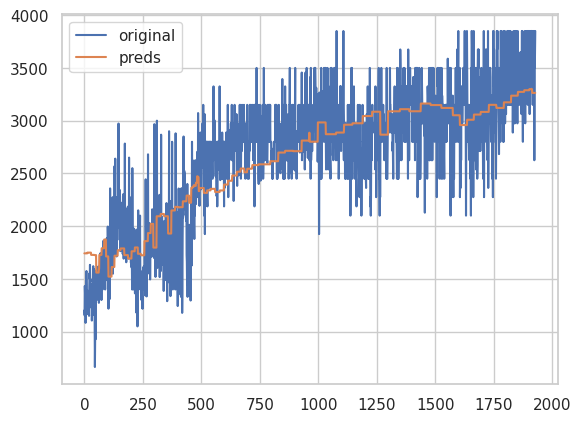

In [56]:
tt = model.predict(rice_data[predictors])

plt.plot(rice_data[target], '-', label="original")
plt.plot(tt, label="preds")

plt.legend()

In [57]:
model2 = RandomForestRegressor()

In [58]:
metrics = []
for train_i, test_i in data_split.split(rice_data[predictors]):
    X_train, X_test = rice_data[predictors].iloc[train_i], rice_data[predictors].iloc[test_i]
    y_train, y_test = rice_data[target].iloc[train_i], rice_data[target].iloc[test_i]
    
    model2.fit(X_train, y_train)
    predictions = model2.predict(X_test)
    metrics.append([mean_squared_error(y_test, predictions), r2_score(y_test, predictions)])

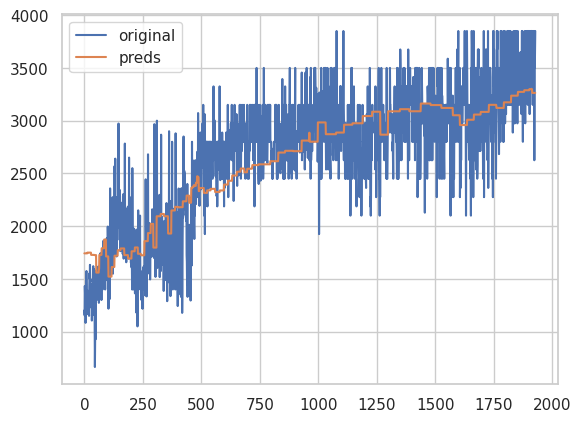

In [59]:
tt = model.predict(rice_data[predictors])

plt.plot(rice_data[target], '-', label="original")
plt.plot(tt, label="preds")

plt.legend()